## Introduction and Problem Statement
## Introduction 
Banks conduct direct marketing campaigns to encourage customers to subscribe to financial products such as term deposits.

## Objective 
To predict whether a customer will accept a marketing offer for a personal loan. 

## Problem Statement
The goal is to determine which customers are most likely to accept a marketing offer and develop a predictive model that improves campaign effectiveness.

## Dataset Understanding and Description 
## Common Features 
| Feature   | Description                      |
| --------- | -------------------------------- |
| age       | Customer age                     |
| job       | Occupation                       |
| marital   | Marital status                   |
| education | Education level                  |
| balance   | Account balance                  |
| housing   | Housing loan status              |
| loan      | Existing personal loan           |
| y         | Accepted offer (Target Variable) |

## Data Cleaning and Preparation

In [1]:
# Import libraries 
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
# Load dataset
bank = pd.read_csv(r"C:\Users\UDDYBON\Downloads\bank.csv")

In [3]:
# Dataset information 
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [4]:
# Missing values 
bank.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [5]:
# Duplicates 
bank.duplicated().sum()

np.int64(0)

In [12]:
# Convert categorical variables 
bank = pd.get_dummies(bank,
                      drop_first=True)

## Basic Data Exploration

In [13]:
# Load original dataset
bank_original = pd.read_csv(r"C:\Users\UDDYBON\Downloads\bank.csv")

# Create encoded dataset for modeling
bank = pd.get_dummies(bank_original, drop_first=True)

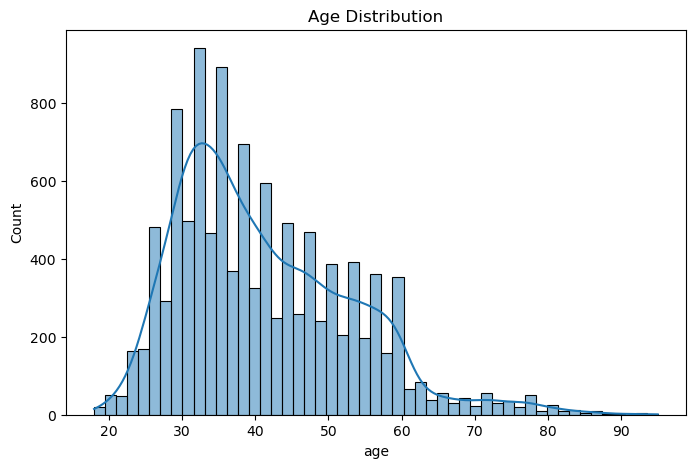

In [14]:
# Age Distribution 
plt.figure(figsize=(8,5)) 

sns.histplot(bank["age"],
             kde=True)

plt.title("Age Distribution")
plt.show()

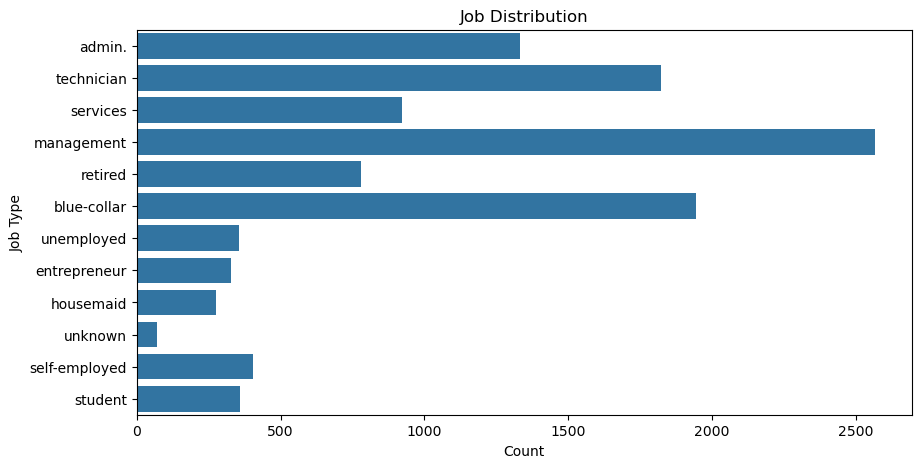

In [15]:
# Job Distribution
plt.figure(figsize=(10,5))

sns.countplot(y="job", 
              data=bank_original)

plt.title("Job Distribution")
plt.xlabel("Count")
plt.ylabel("Job Type")
plt.show()

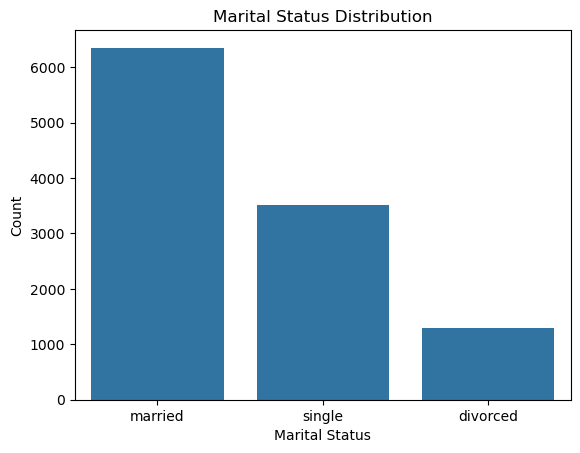

In [16]:
# Marital Status Distribution 
sns.countplot(x="marital",
              data=bank_original)

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

## Model Training and Testing 

In [17]:
# Defining X and Y 
# Features (independent variables)
X = bank.drop("deposit_yes",
              axis=1)

#Target variable (accepted offer or not)
y = bank["deposit_yes"]

In [18]:
# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

## Logistic Regression

In [19]:
# Import model
from sklearn.linear_model import LogisticRegression

In [20]:
# Create model 
model = LogisticRegression(max_iter=15000)

In [21]:
# Train model
model.fit(X_train,
          y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Decision Tree

In [22]:
# Import model 
from sklearn.tree import DecisionTreeClassifier

In [23]:
# Create model 
model = DecisionTreeClassifier(random_state=42)

In [24]:
# Train model 
model.fit(X_train,
          y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [25]:
# Predictions 
predictions = model.predict(X_test)

## Evaluation Metrics

In [26]:
# Accuracy 
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,
                          predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7895208240035826


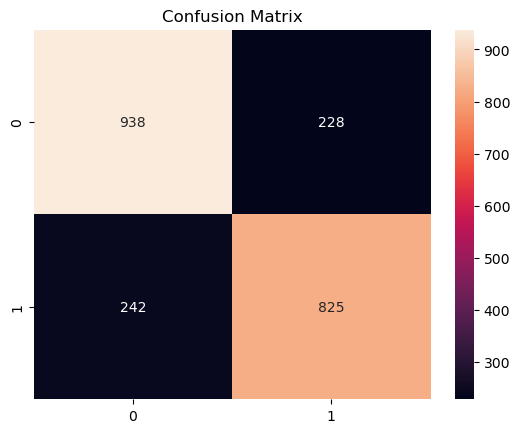

In [27]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,
                      predictions)

sns.heatmap(cm,
            annot=True,
            fmt="d")

plt.title("Confusion Matrix")
plt.show()

## Customer Group Analysis

In [28]:
# Age group vs Acceptance 
bank["Age_Group"] = pd.cut(bank["age"],
                           bins=[18,30,45,60,100],
                           labels=["18-30",
                                   "31-45",
                                   "46-60",
                                   "60+"])

pd.crosstab(bank["Age_Group"],
            bank["deposit_yes"])

deposit_yes,False,True
Age_Group,,
18-30,861,1138
31-45,3177,2345
46-60,1725,1297
60+,109,502


In [29]:
# Create a fresh copy of the original data 
bank_original = pd.read_csv(r"C:\Users\UDDYBON\Downloads\bank.csv")

In [30]:
# Verification 
bank_original.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')

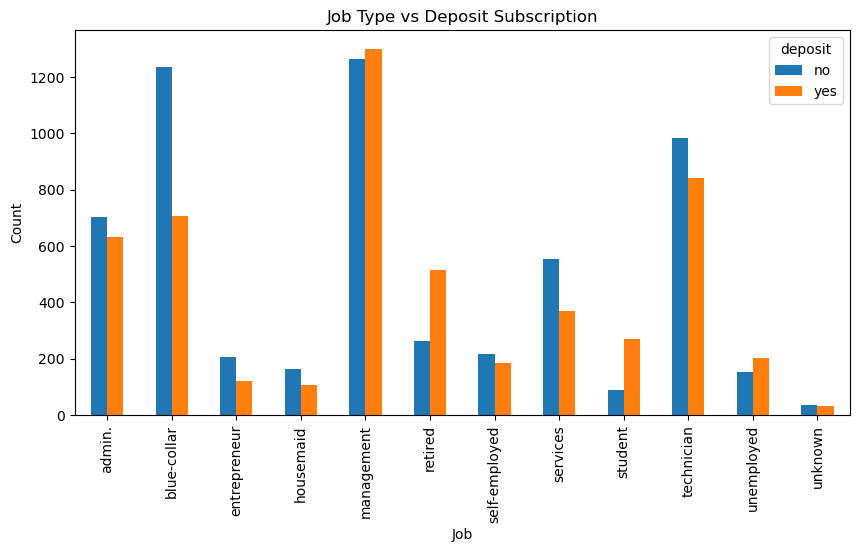

In [31]:
# Job vs Acceptance 
pd.crosstab(bank_original["job"],
            bank_original["deposit"]).plot(kind="bar",
                                          figsize=(10,5))

plt.title("Job Type vs Deposit Subscription")
plt.xlabel("Job")
plt.ylabel("Count")
plt.show()

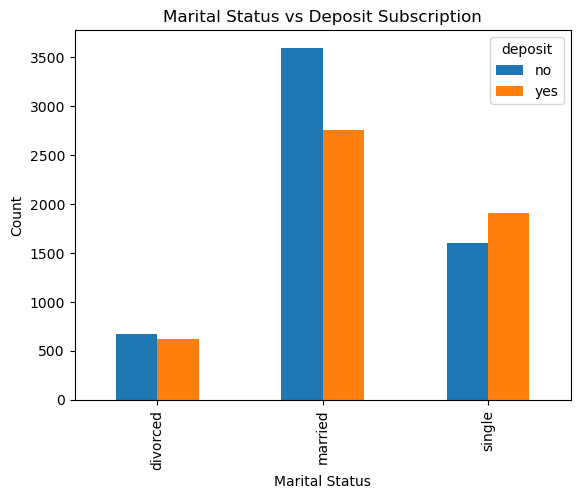

In [32]:
# Marital status vs Acceptance 
pd.crosstab(bank_original["marital"],
            bank_original["deposit"]).plot(kind="bar")

plt.title("Marital Status vs Deposit Subscription")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

In [33]:
# Job Acceptance Rate 
job_acceptance = pd.crosstab(bank_original["job"],
                             bank_original["deposit"],
                             normalize="index") * 100

print(job_acceptance)

deposit               no        yes
job                                
admin.         52.698651  47.301349
blue-collar    63.580247  36.419753
entrepreneur   62.500000  37.500000
housemaid      60.218978  39.781022
management     49.298519  50.701481
retired        33.676093  66.323907
self-employed  53.827160  46.172840
services       60.021668  39.978332
student        25.277778  74.722222
technician     53.922106  46.077894
unemployed     43.417367  56.582633
unknown        51.428571  48.571429


In [34]:
# Marital Acceptance Rate 
marital_acceptance = pd.crosstab(bank_original["marital"],
                                 bank_original["deposit"],
                                 normalize="index") * 100

print(marital_acceptance)

deposit          no        yes
marital                       
divorced  51.894818  48.105182
married   56.621005  43.378995
single    45.650938  54.349062


## Conclusion and Key Insight
## Conclusion
The Bank Marketing dataset was explored to understand customer characteristics associated with accepting a marketing offer. A classification model was trained to predict customer acceptance, and customer groups were analyzed to identify high-response segments.

## Key Insights
1) Age Distribution
* The age distribution is positively skewed.
* Most customers fall within the middle-age range.
* Very young and very old customers make up a smaller proportion of the population.

2) Job Distribution

From the job chart:
* Management and blue-collar occupations represent a significant share of customers.
* Some occupations are much less represented.

3) Marital Status Distribution
* Married customers appear to form the largest group.
* Single customers represent the second-largest segment.
* Divorced customers constitute the smallest group.

4) Customer Group Analysis

Job Type

The Job vs Deposit chart suggests:
* Certain occupations show higher acceptance rates than others.
* Management, retired, and professional groups often demonstrate stronger campaign responses.

Marital Status

The Marital Status vs Deposit chart indicates:
* Acceptance behavior differs across marital categories.
* Some groups appear more responsive to marketing offers than others.

Age Groups

The Age Group analysis suggests:
* Middle-aged customers are among the most responsive segments.
* Younger and older age groups may exhibit lower acceptance rates.

Model Performance

From the confusion matrix:
* The model correctly classified a substantial number of customers.
* Both accepted and non-accepted responses were identified reasonably well.
* Accuracy indicates that the model can support future marketing targeting efforts.

## Business Insight
Marketing campaigns should focus on customer segments that exhibit higher acceptance rates. Targeted campaigns are likely to improve conversion rates and reduce marketing costs.